In [1]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2
#import path libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from utils import psf
from utils import plotting
from utils import zernike

In [2]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [3]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05
L_ffp = 0.0065             # FFP size [mm]
grid_ffp = 64
grid_bfp = 64

In [8]:
microscope = psf.Microscope(N_order = N_order,
                            lambd = lambd,
                            n = n,
                            num_apt = num_apt,
                            f = f,
                            mag = mag,
                            w_0 = w_0,
                            L_bfp = L_bfp,
                            grid_bfp = grid_bfp)

grid = psf.Centered_Square_Grid(L_ffp = L_ffp,
                                grid_ffp = grid_ffp,
                                z_level = 0)

mask = psf.Bead_Image(grid = grid,
                            xs = [0.0],
                            ys = [0.0],
                            bead_sizes = [0.0001])

xs, ys = grid.get_xy()


modes = [[-2,2],
         [2,2],
         [-3,3],
         [3,3],
         [0,4],
         [-4,4],
         [-2,4],
         [2,4],
         [4,4],
         [-5,5],
         [-3, 5],
         [-1, 5],
         [1, 5],
         [3, 5],
         [5,5]]

rng = np.random.default_rng(1)
aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=rng.normal(0, 1, len(modes)),
    RMS_desired=0.2,
    alpha=microscope.alpha,
)

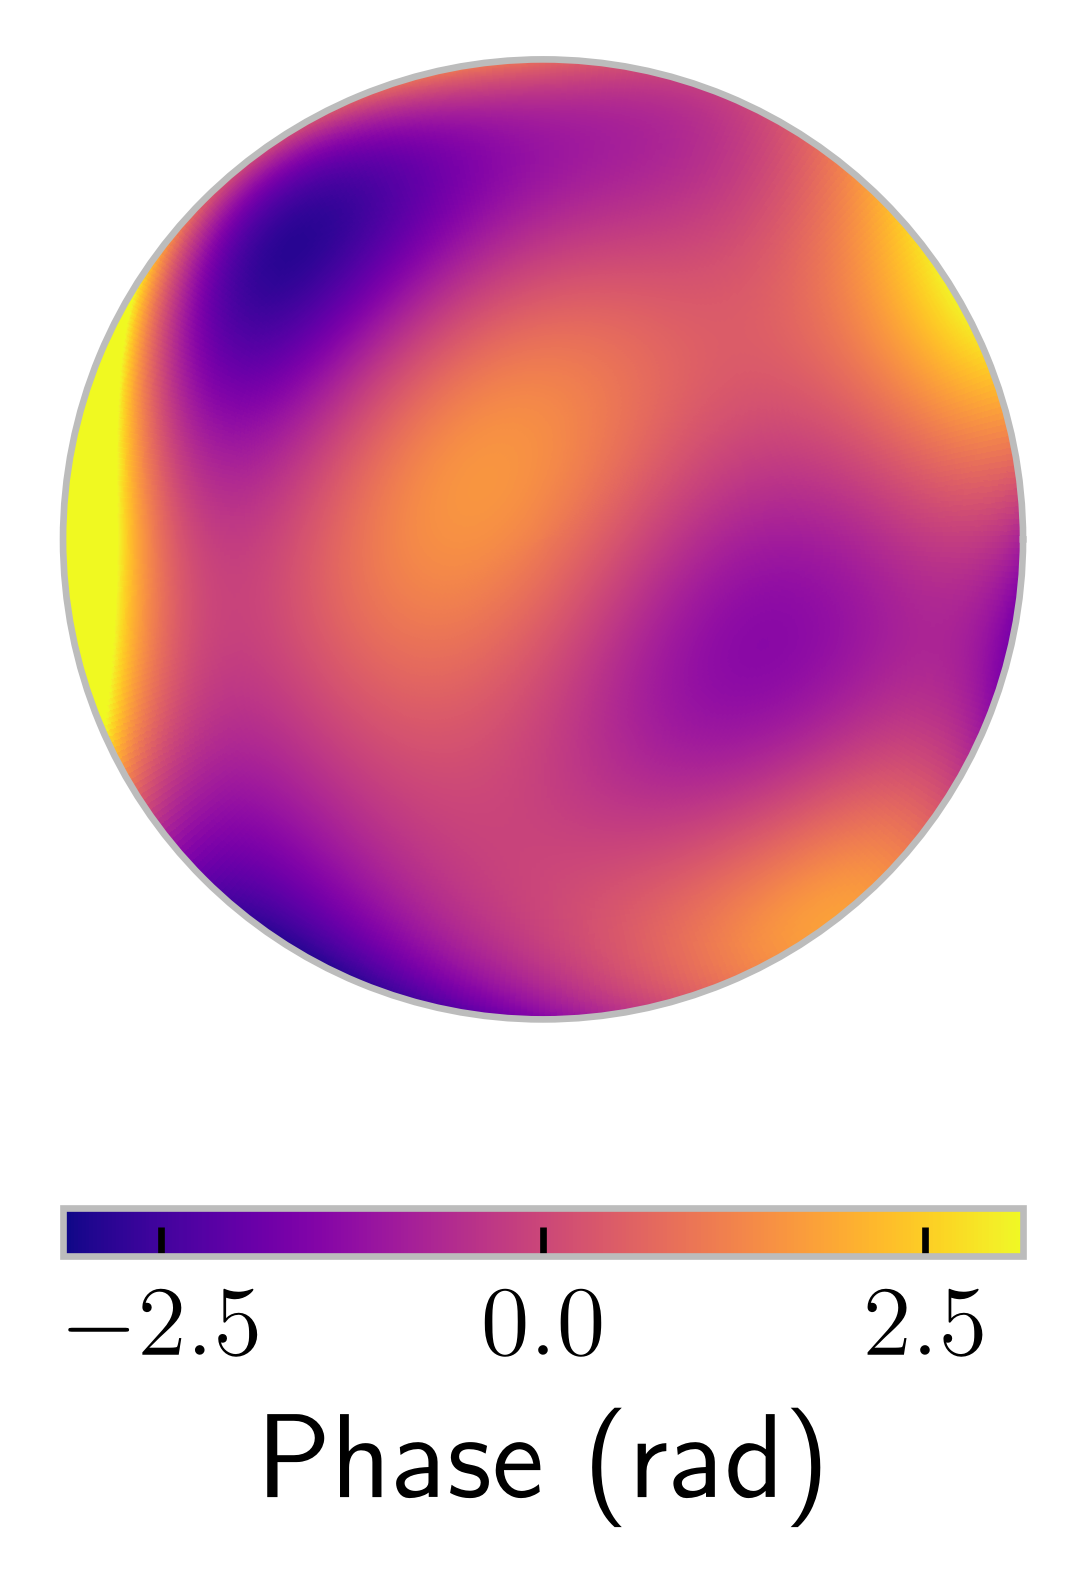

(<Figure size 1200x1800 with 2 Axes>, <PolarAxes: >)

In [9]:
plotting.zernike_plot(aberration.construct_map(microscope.alpha), microscope.alpha)

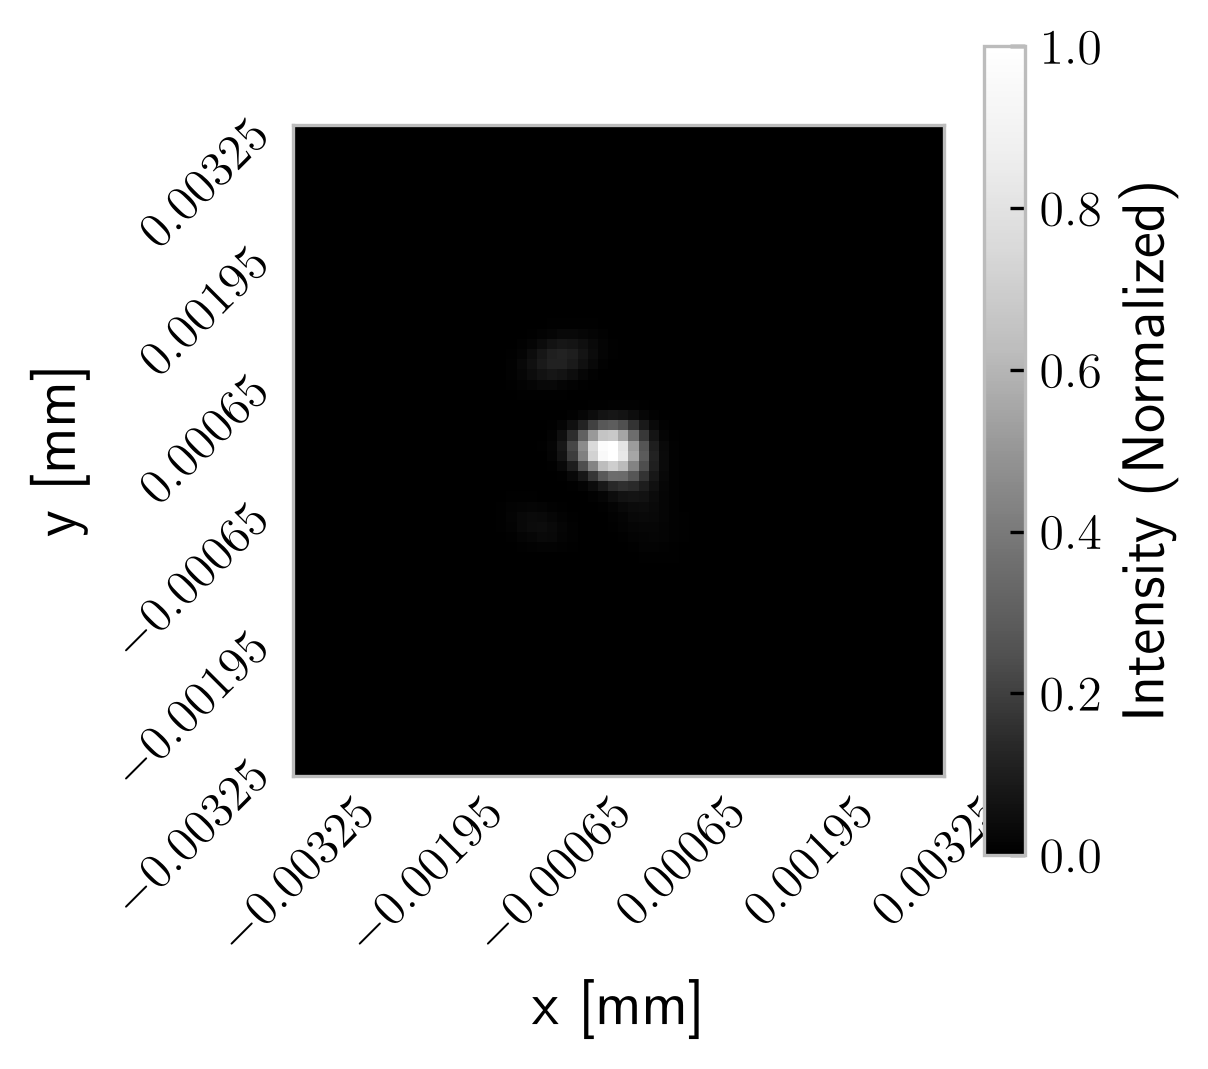

(<Figure size 1050x1050 with 2 Axes>, <Axes: xlabel='x [mm]', ylabel='y [mm]'>)

In [11]:
xs, ys, aberrated_img = microscope.compute_image(image = mask,
                         aberration = aberration,
                         mode = "vector",
                         norm = False)

plotting.plot_intensity(xs, ys, aberrated_img)

In [12]:
z_sample_levels = np.arange(-0.002, 0.002, 0.00010)

eps = 0.000001
z_image_levels = np.arange(-0.002, 0.002, 0.0005)

# Acquire every focal plane with three known spherical diversities (waves).
focal_positions = z_image_levels.copy()
diversity_strengths = [0.0, -0.1, 0.1]
z_image_levels = np.tile(focal_positions, len(diversity_strengths))
diversities = [
    zernike.Aberration([[-2, 2]], [strength])
    for strength in diversity_strengths
    for _ in focal_positions
]


In [13]:
mask_3D = psf.random_bead_img_3D(grid = grid,
                                 z_levels = z_sample_levels,
                                 num_beads = 5,
                                 bead_size = 0.001)

In [14]:
x, y, z, I = microscope.compute_image_3D(image = mask_3D,
                            aberration = aberration,
                            focal_z_levels = z_image_levels,
                            diversities = diversities)

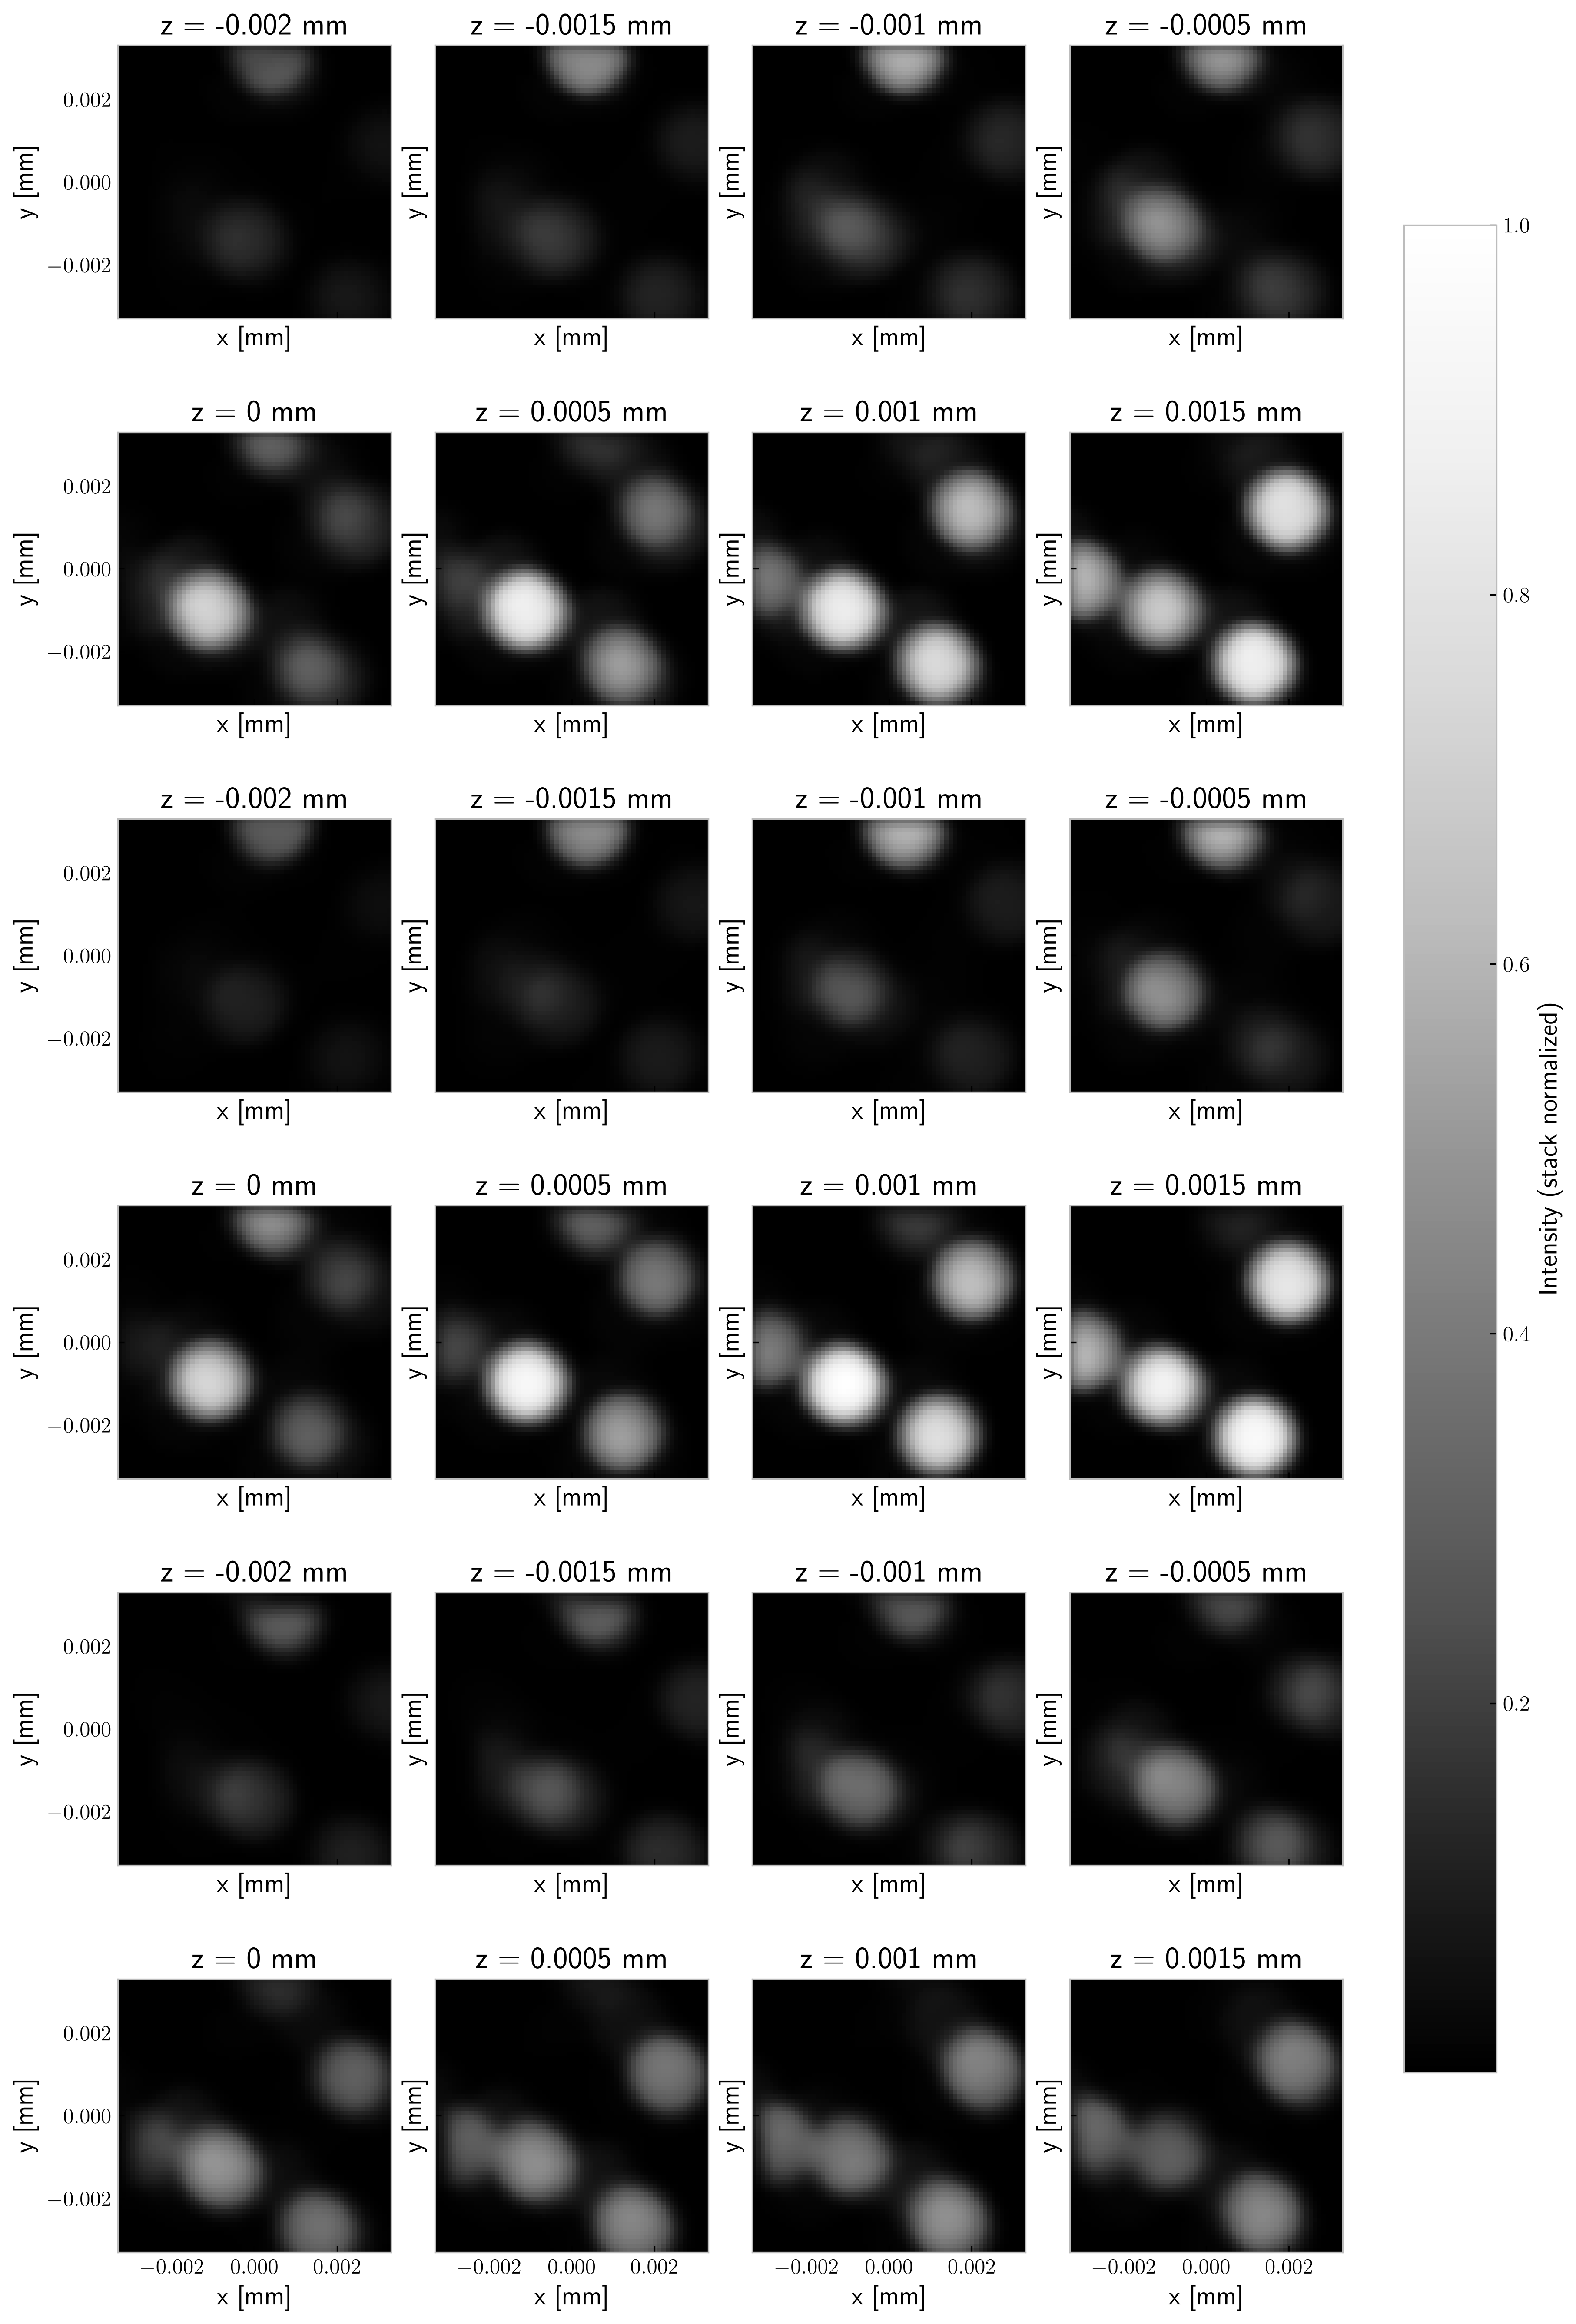

In [15]:
fig, axs = plotting.plot_image_stack(x, y, z, I, ncols=4)

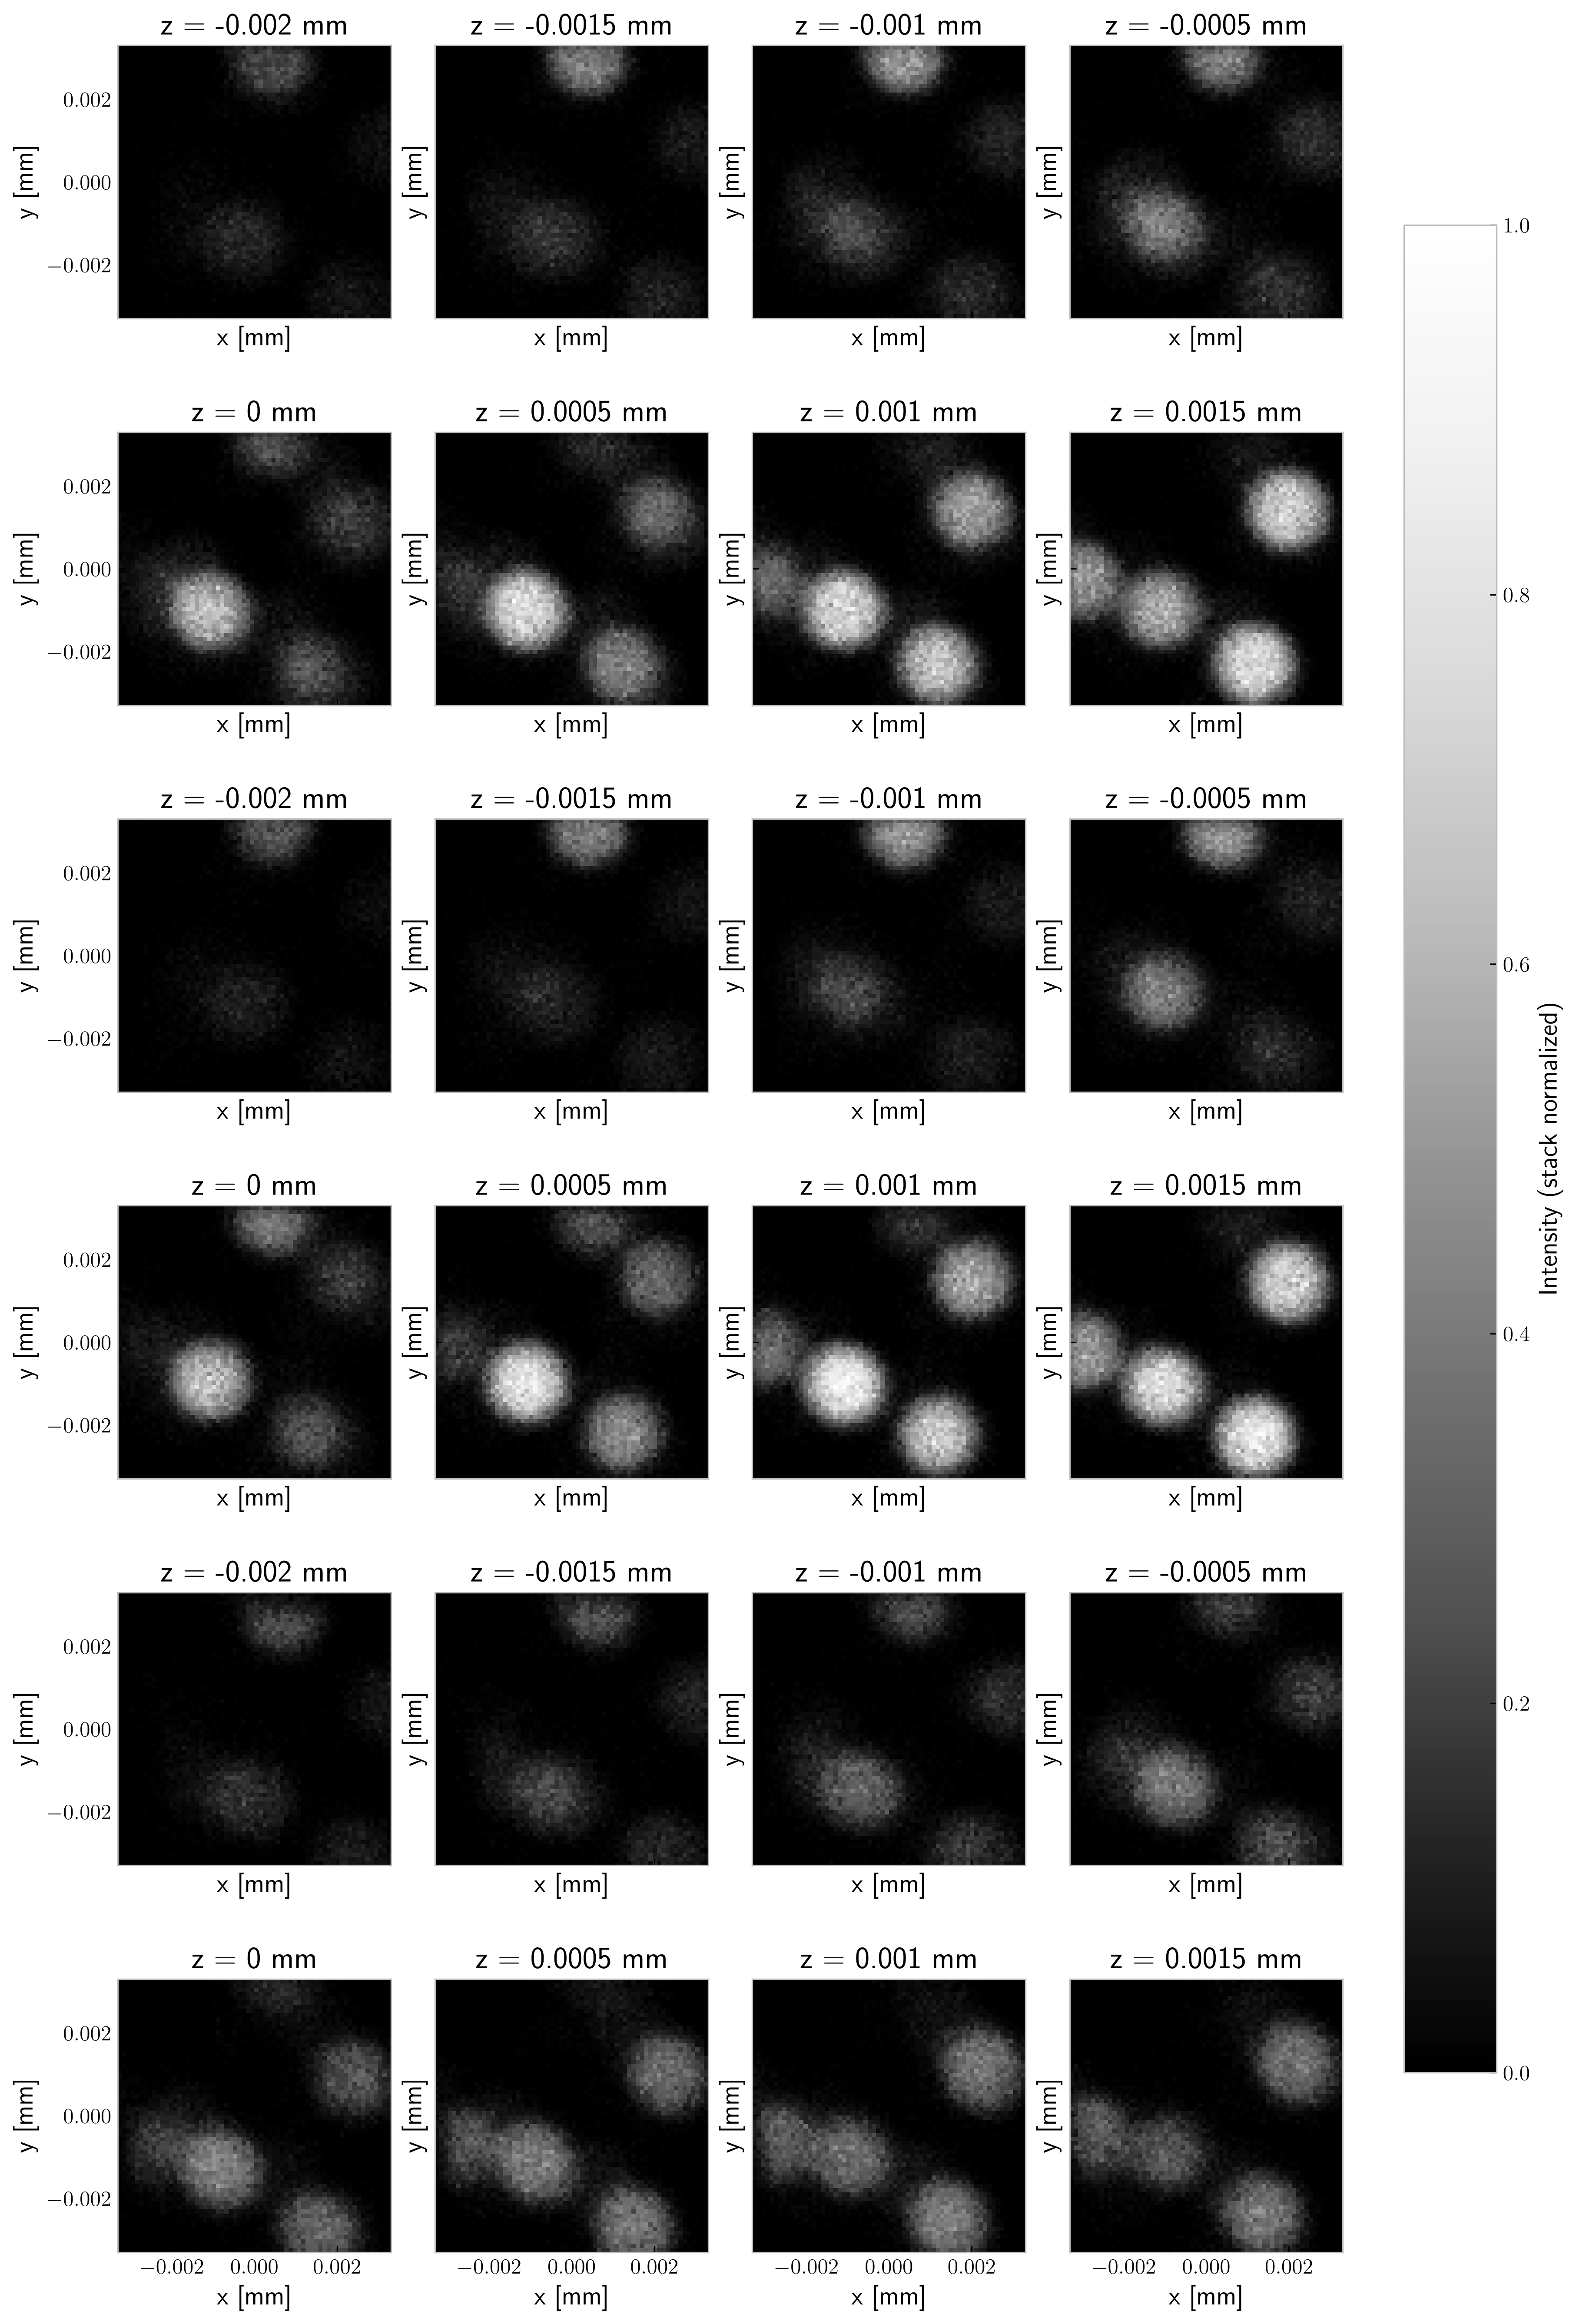

In [16]:
rng = np.random.default_rng(42)

I_clean = np.asarray(I, dtype=float).copy()

#calibrate ONCE using this stack as the reference acquisition.
#reuse this conversion for subsequent aberrations with the same settings.
reference_total_counts = 1000000  # Expected signal counts over the full stack
counts_per_unit = reference_total_counts / I_clean.sum()

background_counts = 0.0  #expected counts per pixel per acquired image
expected_counts = counts_per_unit * I_clean + background_counts
counts = rng.poisson(expected_counts)
I_noisy = counts
# Return to the units expected by your existing reconstruction code.
#I_noisy = (counts.astype(float) - background_counts) / counts_per_unit

fig, axs = plotting.plot_image_stack(x, y, z, I_noisy, ncols=4)

In [17]:
from optimization import reconstruction

In [21]:
reconstructed_img = reconstruction.estimate_sample_3D(microscope = microscope,
                                  grid = grid,
                                  images = I_noisy,
                                  focal_z_levels = z_image_levels,
                                  diversities = diversities,
                                  sample_z_levels = z_sample_levels,
                                  aberration = aberration,
                                  rho = 1e46)

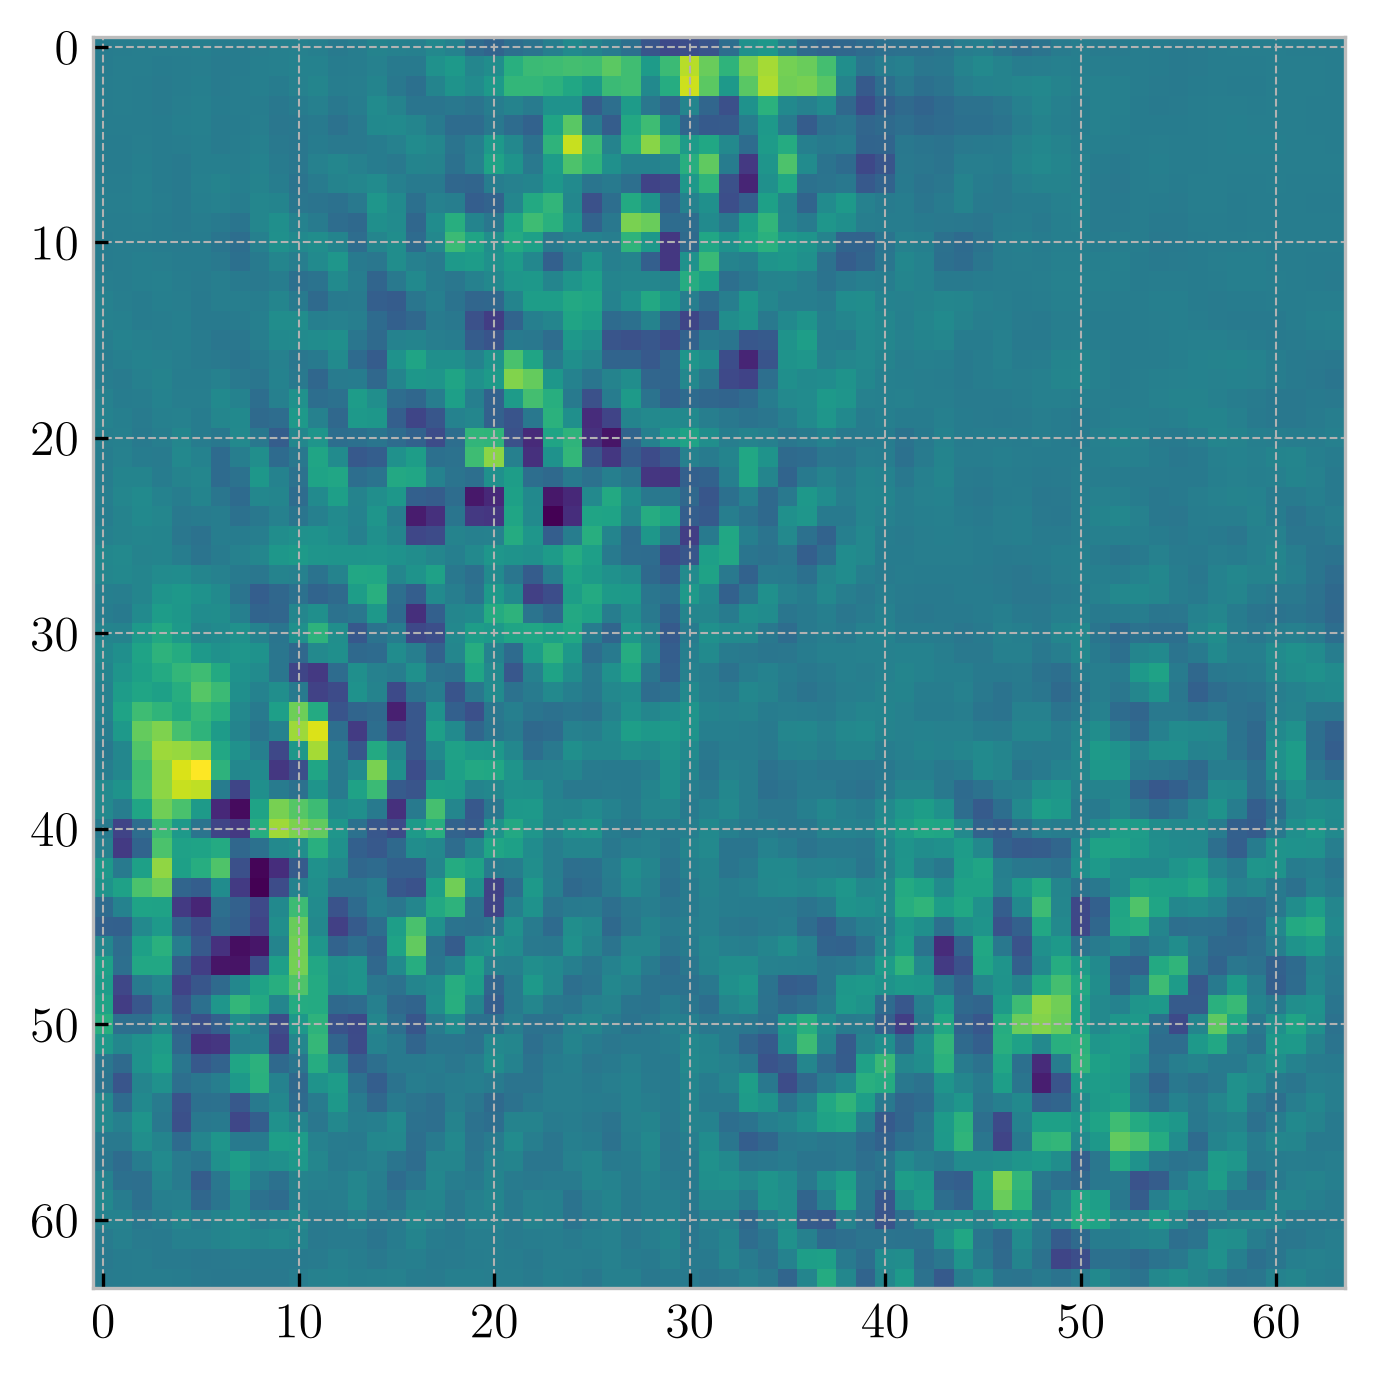

In [22]:
plt.imshow(reconstructed_img.image_mask[35])

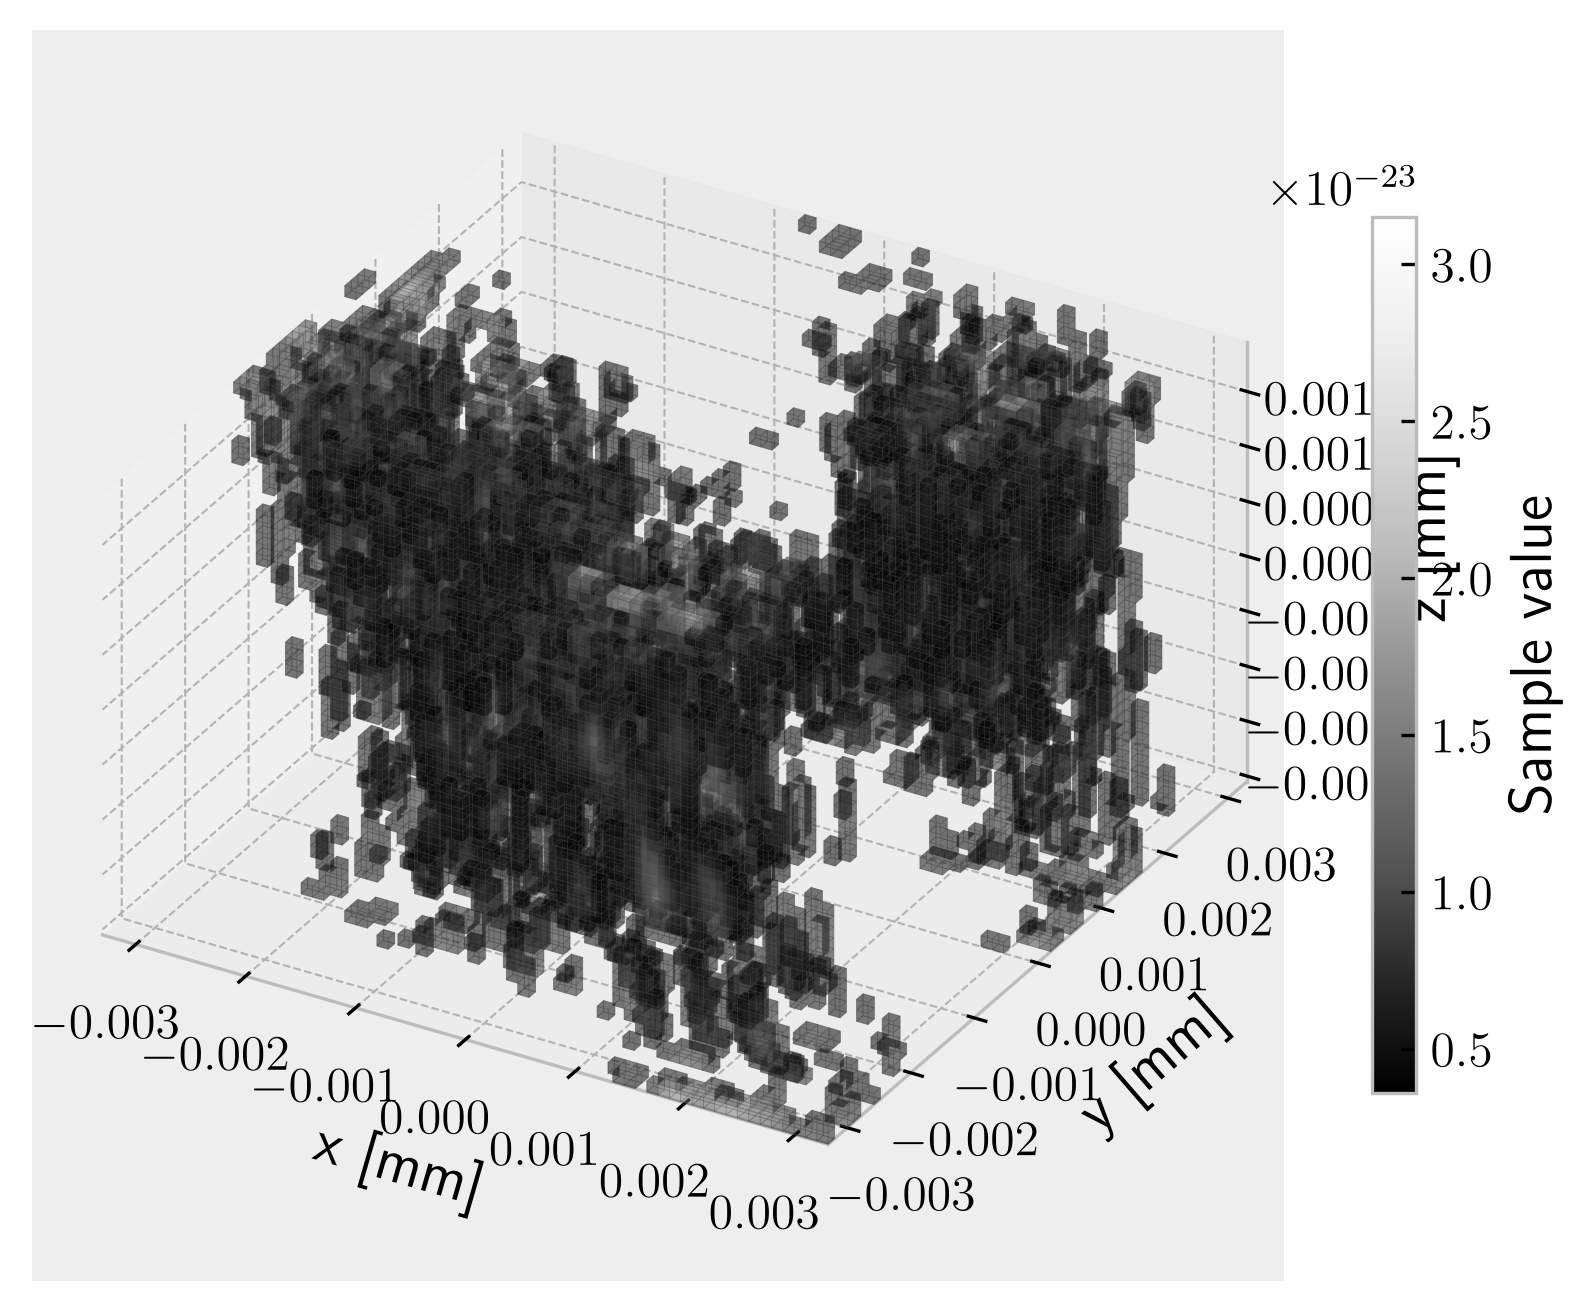

In [23]:
fig, ax = plotting.plot_sample_3D(reconstructed_img, np.percentile(reconstructed_img.image_mask,92))

In [24]:
estimated, info = reconstruction.optimize_aberration_3D(
    microscope=microscope,
    grid=grid,
    images=I_noisy,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    modes= modes,
    rho=1e46,
    diversities=diversities,
    initial_strengths=[0.0] * len(modes),
)

Iteration 0: loss=1.0273803949e+11, strengths (waves)=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Iteration 1: loss=4.0628491495e+10, strengths (waves)=[ 0.09902372  0.00488417 -0.00804385 -0.01691862 -0.1        -0.01433675
  0.04185121  0.00439756  0.02560136 -0.01257127  0.02282946 -0.01357896
  0.00917114  0.02489914  0.01323333]
Iteration 2: loss=3.1200421468e+10, strengths (waves)=[ 0.07402372  0.00255249 -0.00151974 -0.00879109 -0.10593542 -0.00732335
  0.02366916  0.00495156  0.01172621 -0.02907795  0.04031493 -0.00188598
 -0.00476605  0.04811259  0.02073412]
Iteration 3: loss=2.9148351079e+10, strengths (waves)=[ 0.06644391  0.01183201 -0.00704544 -0.03379109 -0.12490491  0.00177486
  0.00822369  0.00129498  0.01206079 -0.05053567  0.0214189   0.00985981
 -0.00431846  0.04372051  0.03272717]
Iteration 4: loss=2.5715653858e+10, strengths (waves)=[ 0.07518644  0.01396786 -0.00773225 -0.05067574 -0.11640212 -0.01037174
  0.00774304  0.00383648  0.00826172 -0.0417547   0.037248

(0.0, 0.3)

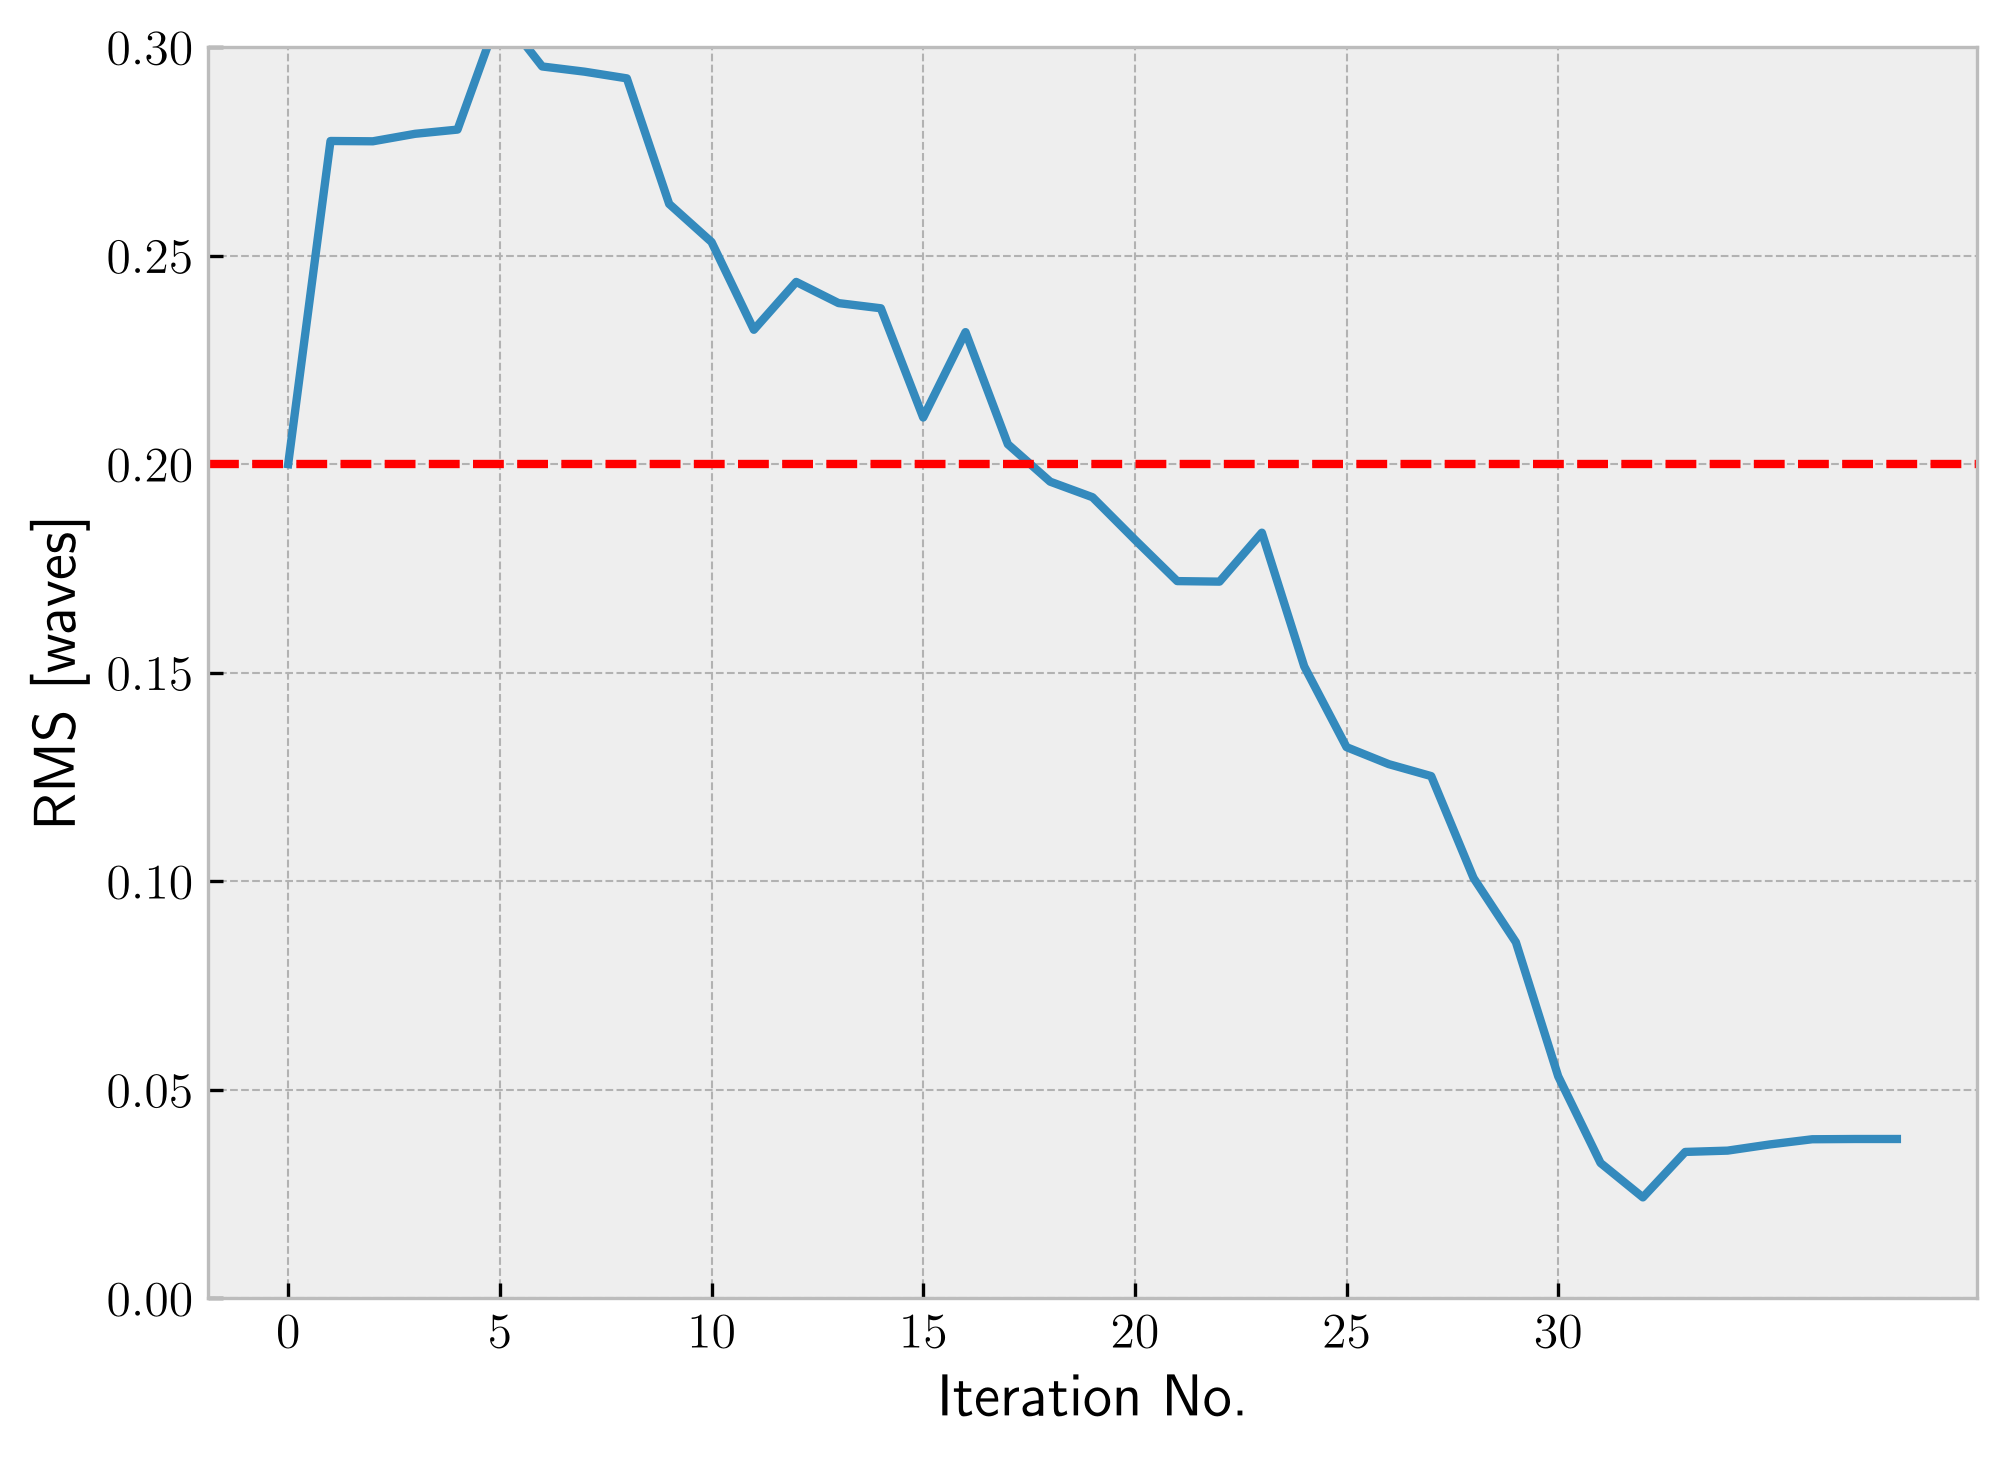

In [28]:
rms_difs = []
for i in range(len(info["history"])):
    s = info["history"][i]["strengths"]
    a = zernike.Aberration(modes, s)
    dif = zernike.zernike_RMS_difference(aberration - a,zernike.EmptyAberration(), microscope.alpha)
    rms_difs.append(dif)

fig, ax = plt.subplots()
ax.plot(rms_difs)
ax.set_xlabel("Iteration No.")
ax.set_xticks([0, 5, 10, 15, 20, 25, 30])
ax.set_ylabel("RMS [waves]")
ax.axhline(rms_difs[0], color = "red", ls = "dashed")
ax.set_ylim(0, 0.30)

In [27]:
from IPython.display import HTML, display

aberration_anim, object_anim = plotting.animate_reconstruction(
    info=info,
    modes=estimated.modes,
    microscope=microscope,
    grid=grid,
    images=I_noisy,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    rho=1e46,
    diversities=diversities,
    percentile=92,  # Fixed voxel threshold from the final object's percentile
    interval=500,   # Milliseconds per frame
    stride=1,       # Show every recorded iteration
)

In [29]:
aberration_anim.save("aberration_complex.gif", writer="pillow", fps=4)
object_anim.save("object_complex.gif", writer="pillow", fps=4)